# Satellite Land-Cover Classifier

This notebook trains a ResNet50 classifier on EuroSAT.



## 1. Setup

In [1]:
!pip install rasterio -q

In [2]:
import os
import shutil
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from PIL import Image
import rasterio
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


## 2. Load the EuroSAT dataset

Download the EuroSAT RGB dataset (from Kaggle, GitHub, or Hugging Face) and
extract it so the folder structure looks like:

```
EuroSAT_RGB/
    AnnualCrop/
    Forest/
    HerbaceousVegetation/
    Highway/
    Industrial/
    Pasture/
    PermanentCrop/
    Residential/
    River/
    SeaLake/
```

Update `dataset_root` below to point at that folder (e.g. after uploading a
zip and extracting it, or mounting Google Drive).

In [4]:
import zipfile

with zipfile.ZipFile('/content/EuroSAT.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/EuroSAT_RGB')

In [5]:
import os
print(os.listdir('/content/EuroSAT_RGB'))

['2750']


In [6]:
dataset_root = '/content/EuroSAT_RGB/2750'  # or whatever the nested folder is called

In [7]:
import os
print(os.listdir('/content/EuroSAT_RGB/2750'))

['PermanentCrop', 'Industrial', 'River', 'Residential', 'SeaLake', 'Highway', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Forest']


In [8]:
dataset_root = '/content/EuroSAT_RGB/2750'  # <-- update this path

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=dataset_root, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

print(f"Total: {len(full_dataset)} | Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Classes: {full_dataset.classes}")

Total: 27000 | Train: 21600 | Val: 2700 | Test: 2700
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [9]:
num_workers = os.cpu_count()

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=True)

## 3. Build the model (transfer learning from ResNet50)

In [10]:
model = models.resnet50(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


## 4. Train the final layer (frozen backbone)

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    epoch_start = time.time()
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    duration = time.time() - epoch_start
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, '
          f'Val Accuracy: {val_accuracy:.4f}, Time: {duration:.2f}s')

Epoch 1/10, Loss: 0.4862, Val Accuracy: 0.9144, Time: 79.50s
Epoch 2/10, Loss: 0.2839, Val Accuracy: 0.9281, Time: 82.78s
Epoch 3/10, Loss: 0.2650, Val Accuracy: 0.9267, Time: 81.84s
Epoch 4/10, Loss: 0.2519, Val Accuracy: 0.9274, Time: 81.89s
Epoch 5/10, Loss: 0.2332, Val Accuracy: 0.9411, Time: 82.09s
Epoch 6/10, Loss: 0.2269, Val Accuracy: 0.9378, Time: 82.02s
Epoch 7/10, Loss: 0.2290, Val Accuracy: 0.9326, Time: 81.93s
Epoch 8/10, Loss: 0.2185, Val Accuracy: 0.9444, Time: 81.61s
Epoch 9/10, Loss: 0.2184, Val Accuracy: 0.9352, Time: 81.72s
Epoch 10/10, Loss: 0.2176, Val Accuracy: 0.9344, Time: 81.04s


## 5. Fine-tune the whole network at a lower learning rate

In [12]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs_finetune = 5

for epoch in range(num_epochs_finetune):
    epoch_start = time.time()
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    duration = time.time() - epoch_start
    print(f'Fine-tune Epoch {epoch+1}/{num_epochs_finetune}, Loss: {running_loss/len(train_loader):.4f}, '
          f'Val Accuracy: {val_accuracy:.4f}, Time: {duration:.2f}s')

Fine-tune Epoch 1/5, Loss: 0.2213, Val Accuracy: 0.9722, Time: 233.11s
Fine-tune Epoch 2/5, Loss: 0.0901, Val Accuracy: 0.9719, Time: 230.27s
Fine-tune Epoch 3/5, Loss: 0.0665, Val Accuracy: 0.9774, Time: 230.69s
Fine-tune Epoch 4/5, Loss: 0.0630, Val Accuracy: 0.9611, Time: 230.23s
Fine-tune Epoch 5/5, Loss: 0.0572, Val Accuracy: 0.9700, Time: 230.69s


## 6. Save the trained model

In [13]:
torch.save(model.state_dict(), "resnet50_eurosat.pth")
print("Model saved to resnet50_eurosat.pth")

Model saved to resnet50_eurosat.pth


## 7. Evaluate on the held-out test set

In [14]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = ['AnnualCrop', 'Forest', 'HerbVeg', 'Highway', 'Industrial',
               'Pasture', 'PermCrop', 'Residential', 'River', 'SeaLake']

print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

  AnnualCrop       0.98      0.95      0.96       311
      Forest       0.99      0.98      0.99       317
     HerbVeg       0.97      0.98      0.97       287
     Highway       0.96      0.92      0.94       256
  Industrial       0.99      0.98      0.98       246
     Pasture       0.94      0.96      0.95       199
    PermCrop       0.93      0.99      0.96       224
 Residential       1.00      0.98      0.99       300
       River       0.95      0.98      0.97       267
     SeaLake       1.00      1.00      1.00       293

    accuracy                           0.97      2700
   macro avg       0.97      0.97      0.97      2700
weighted avg       0.97      0.97      0.97      2700



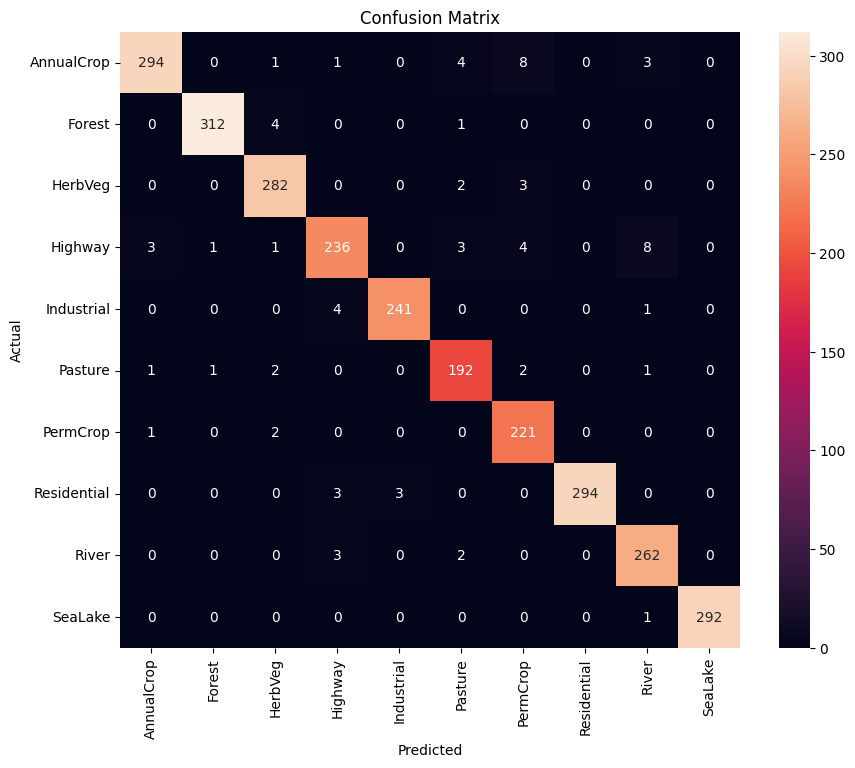

In [15]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

In [16]:
from google.colab import files
files.download('resnet50_eurosat.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# Part 2: Deforestation Detection

From here on, we reuse the trained `model` to classify two Sentinel-2 images
from different dates and compare the results.

Update the paths below to point at your downloaded Sentinel-2 L2A `.tiff`
band files (B02 = blue, B03 = green, B04 = red) for each time period.

In [17]:
import zipfile

with zipfile.ZipFile('/2018.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/2018_extracted')

with zipfile.ZipFile('/2024.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/2024_extracted')

In [18]:
period_1_band_paths = {
    'B02': '/content/2018_extracted/2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B02_(Raw).tiff',
    'B03': '/content/2018_extracted/2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B03_(Raw).tiff',
    'B04': '/content/2018_extracted/2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B04_(Raw).tiff',
}

period_2_band_paths = {
    'B02': '/content/2024_extracted/2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B02_(Raw).tiff',
    'B03': '/content/2024_extracted/2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B03_(Raw).tiff',
    'B04': '/content/2024_extracted/2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B04_(Raw).tiff',
}

# Check native resolution -- should be ~10m/pixel for these bands
with rasterio.open(period_1_band_paths['B04']) as src:
    print("Resolution (m/pixel):", src.res)

Resolution (m/pixel): (8.980067283431791e-05, 8.777468839884829e-05)


In [19]:
import rasterio

with rasterio.open(period_1_band_paths['B04']) as src:
    print("Bounds:", src.bounds)
    print("CRS:", src.crs)

Bounds: BoundingBox(left=75.563965, bottom=12.32994, right=75.670738, top=12.421489)
CRS: EPSG:4326


In [20]:
import rasterio

with rasterio.open(period_1_band_paths['B04']) as src:
    bounds = src.bounds
    lat = (bounds.top + bounds.bottom) / 2
    print(f"Bounds: {bounds}")
    print(f"Approximate latitude: {lat:.4f}")

Bounds: BoundingBox(left=75.563965, bottom=12.32994, right=75.670738, top=12.421489)
Approximate latitude: 12.3757


## 8. Combine raw bands into RGB with a percentile stretch (fixes the SeaLake bug)

In [21]:
def load_and_combine_rgb_bands(band_paths, low_pct=2, high_pct=98):
    """
    Loads B04 (red), B03 (green), B02 (blue) and combines into an 8-bit RGB
    image using a percentile stretch instead of a fixed divisor. A fixed
    divisor like /5000 tends to crush real reflectance values into
    near-black pixels, which the model then reads as 'SeaLake'.
    """
    def read_and_stretch(path):
        with rasterio.open(path) as src:
            arr = src.read(1).astype(np.float32)
        lo, hi = np.percentile(arr, [low_pct, high_pct])
        if hi <= lo:
            hi = lo + 1
        arr = np.clip((arr - lo) / (hi - lo), 0, 1)
        return (arr * 255).astype(np.uint8)

    red = read_and_stretch(band_paths['B04'])
    green = read_and_stretch(band_paths['B03'])
    blue = read_and_stretch(band_paths['B02'])

    rgb_array = np.stack([red, green, blue], axis=-1)
    return Image.fromarray(rgb_array)

## 9. Chop into patches at the correct physical scale

Crop at 64x64 pixels (matching EuroSAT's 640m tiles at 10m/pixel), not
224x224 directly -- otherwise each patch covers ~2.24km instead of 640m,
which looks nothing like what the model was trained on.

In [22]:
def chop_image_into_patches(band_paths, native_patch_size=64, output_dir='output_patches'):
    os.makedirs(output_dir, exist_ok=True)

    img = load_and_combine_rgb_bands(band_paths)
    img_width, img_height = img.size
    patches_info = []

    for y in range(0, img_height - native_patch_size + 1, native_patch_size):
        for x in range(0, img_width - native_patch_size + 1, native_patch_size):
            patch = img.crop((x, y, x + native_patch_size, y + native_patch_size))
            filename = f"patch_{x}_{y}.png"
            patch.save(os.path.join(output_dir, filename))
            patches_info.append({'filename': filename, 'x_coord': x, 'y_coord': y})

    print(f"Saved {len(patches_info)} patches ({native_patch_size}px native) to {output_dir}")
    return patches_info

output_patches_period_1_dir = '/content/patches_period_1_fixed'
output_patches_period_2_dir = '/content/patches_period_2_fixed'

# Clear any previous runs
for d in [output_patches_period_1_dir, output_patches_period_2_dir]:
    if os.path.exists(d):
        shutil.rmtree(d)

patches_period_1_info = chop_image_into_patches(period_1_band_paths, output_dir=output_patches_period_1_dir)
patches_period_2_info = chop_image_into_patches(period_2_band_paths, output_dir=output_patches_period_2_dir)

Saved 288 patches (64px native) to /content/patches_period_1_fixed
Saved 288 patches (64px native) to /content/patches_period_2_fixed


## 10. Sanity-check a few patches visually

Before classifying anything, look at a handful of patches. They should look
like recognizable terrain (green/brown/tan patchwork), not uniform dark
squares. If they still look wrong, stop here and fix step 8/9 first --
everything downstream inherits this problem.

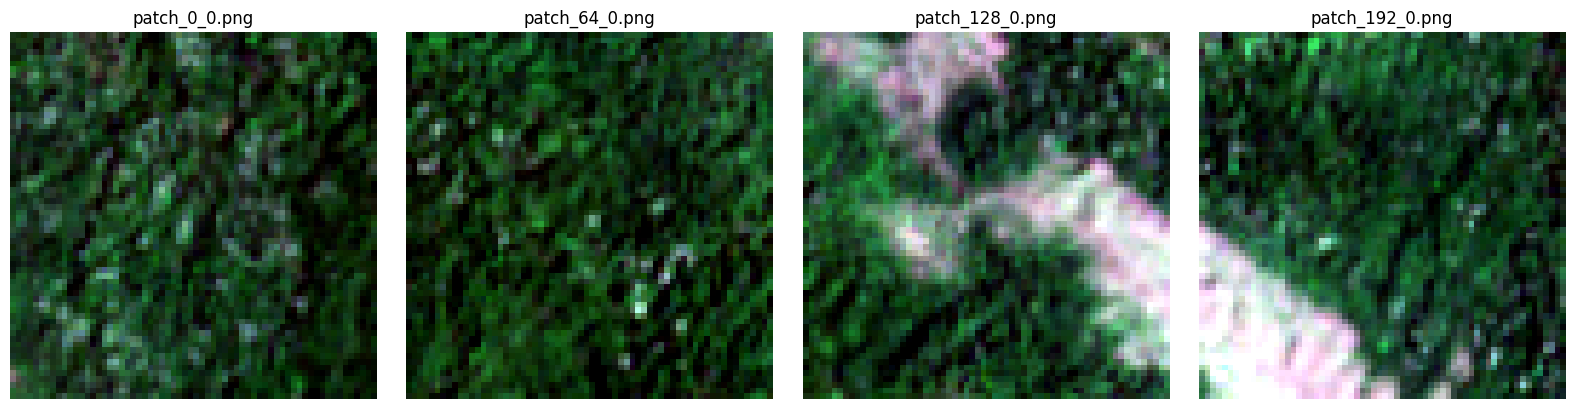

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, patch_info in zip(axes, patches_period_1_info[:4]):
    img = Image.open(os.path.join(output_patches_period_1_dir, patch_info['filename']))
    ax.imshow(img)
    ax.set_title(patch_info['filename'])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [25]:
with rasterio.open(period_1_band_paths['B04']) as src:
    print(src.tags())

{'TIFFTAG_XRESOLUTION': '1', 'TIFFTAG_YRESOLUTION': '1', 'TIFFTAG_RESOLUTIONUNIT': '1 (unitless)', 'AREA_OR_POINT': 'Area'}


In [28]:
for e in all_changes[:15]:
    print(e)

{'x': 0, 'y': 0, 'from_class': 'SeaLake', 'to_class': 'Forest'}
{'x': 64, 'y': 0, 'from_class': 'SeaLake', 'to_class': 'Forest'}
{'x': 128, 'y': 0, 'from_class': 'HerbVeg', 'to_class': 'PermCrop'}
{'x': 192, 'y': 0, 'from_class': 'SeaLake', 'to_class': 'Forest'}
{'x': 256, 'y': 0, 'from_class': 'SeaLake', 'to_class': 'Forest'}
{'x': 320, 'y': 0, 'from_class': 'SeaLake', 'to_class': 'Forest'}
{'x': 384, 'y': 0, 'from_class': 'SeaLake', 'to_class': 'Forest'}
{'x': 512, 'y': 0, 'from_class': 'SeaLake', 'to_class': 'Forest'}
{'x': 576, 'y': 0, 'from_class': 'SeaLake', 'to_class': 'Forest'}
{'x': 704, 'y': 0, 'from_class': 'SeaLake', 'to_class': 'Forest'}
{'x': 768, 'y': 0, 'from_class': 'Forest', 'to_class': 'SeaLake'}
{'x': 832, 'y': 0, 'from_class': 'Highway', 'to_class': 'Forest'}
{'x': 1088, 'y': 0, 'from_class': 'HerbVeg', 'to_class': 'Forest'}
{'x': 64, 'y': 64, 'from_class': 'SeaLake', 'to_class': 'Forest'}
{'x': 128, 'y': 64, 'from_class': 'SeaLake', 'to_class': 'Forest'}


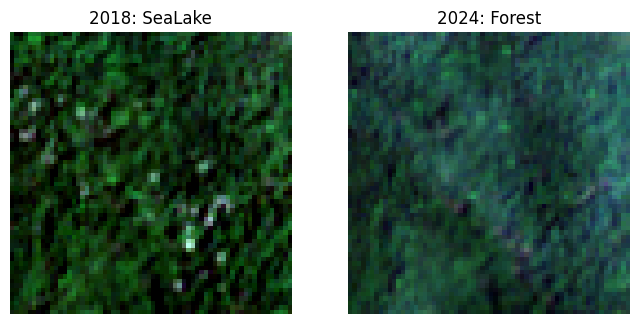

In [29]:
sample = all_changes[1]  # try a few different indices: [1], [5], [10], etc.
x, y = sample['x'], sample['y']

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Image.open(f"{output_patches_period_1_dir}/patch_{x}_{y}.png"))
axes[0].set_title(f"2018: {sample['from_class']}")
axes[1].imshow(Image.open(f"{output_patches_period_2_dir}/patch_{x}_{y}.png"))
axes[1].set_title(f"2024: {sample['to_class']}")
for ax in axes:
    ax.axis('off')
plt.show()

In [30]:
with rasterio.open(period_1_band_paths['B04']) as src:
    arr = src.read(1)
print("Row 0-64 stats:", arr[0:64, 0:64].min(), arr[0:64, 0:64].max(), arr[0:64, 0:64].mean())
print("Row 300-364 stats (middle of image):", arr[300:364, 0:64].min(), arr[300:364, 0:64].max(), arr[300:364, 0:64].mean())

Row 0-64 stats: 708 4627 1716.375732421875
Row 300-364 stats (middle of image): 1029 15840 3465.94970703125


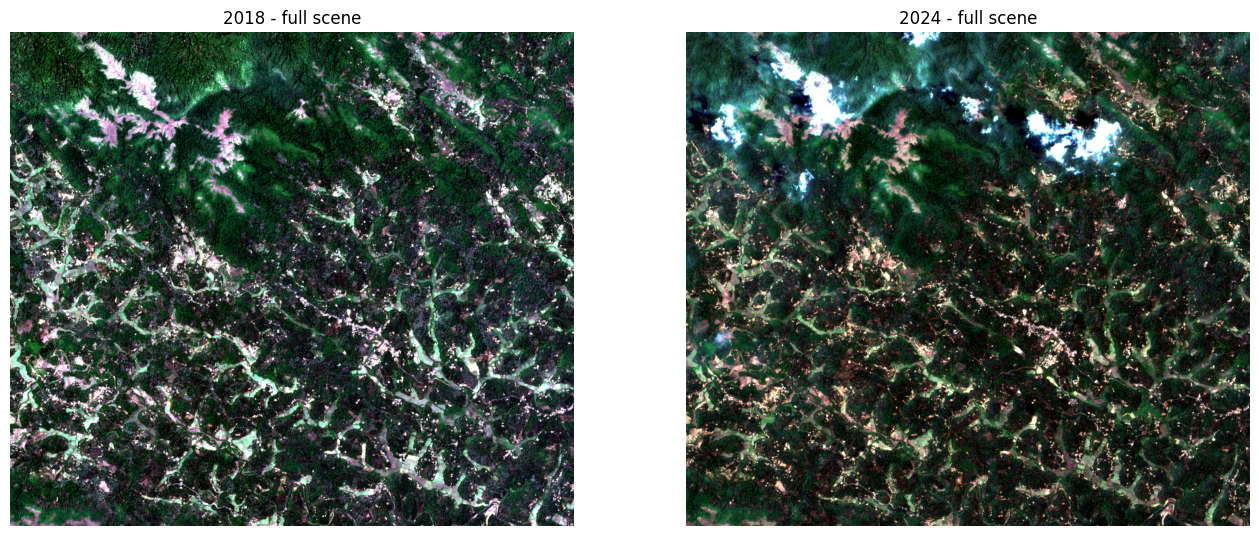

In [31]:
img1 = load_and_combine_rgb_bands(period_1_band_paths)
img2 = load_and_combine_rgb_bands(period_2_band_paths)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(img1)
axes[0].set_title("2018 - full scene")
axes[1].imshow(img2)
axes[1].set_title("2024 - full scene")
for ax in axes:
    ax.axis('off')
plt.show()

In [32]:
def load_and_combine_rgb_bands(band_paths, low_pct=2, high_pct=98, crop_top_frac=0.0):
    def read_and_stretch(path):
        with rasterio.open(path) as src:
            arr = src.read(1).astype(np.float32)
        if crop_top_frac > 0:
            cut = int(arr.shape[0] * crop_top_frac)
            arr = arr[cut:, :]
        lo, hi = np.percentile(arr, [low_pct, high_pct])
        if hi <= lo:
            hi = lo + 1
        arr = np.clip((arr - lo) / (hi - lo), 0, 1)
        return (arr * 255).astype(np.uint8)

    red = read_and_stretch(band_paths['B04'])
    green = read_and_stretch(band_paths['B03'])
    blue = read_and_stretch(band_paths['B02'])
    return Image.fromarray(np.stack([red, green, blue], axis=-1))

In [33]:
def load_and_combine_rgb_bands(band_paths, low_pct=2, high_pct=98, crop_top_frac=0.0):
    def read_and_stretch(path):
        with rasterio.open(path) as src:
            arr = src.read(1).astype(np.float32)
        if crop_top_frac > 0:
            cut = int(arr.shape[0] * crop_top_frac)
            arr = arr[cut:, :]
        lo, hi = np.percentile(arr, [low_pct, high_pct])
        if hi <= lo:
            hi = lo + 1
        arr = np.clip((arr - lo) / (hi - lo), 0, 1)
        return (arr * 255).astype(np.uint8)

    red = read_and_stretch(band_paths['B04'])
    green = read_and_stretch(band_paths['B03'])
    blue = read_and_stretch(band_paths['B02'])
    return Image.fromarray(np.stack([red, green, blue], axis=-1))

In [34]:
def chop_image_into_patches(band_paths, native_patch_size=64, output_dir='output_patches', crop_top_frac=0.0):
    os.makedirs(output_dir, exist_ok=True)
    img = load_and_combine_rgb_bands(band_paths, crop_top_frac=crop_top_frac)
    img_width, img_height = img.size
    patches_info = []

    for y in range(0, img_height - native_patch_size + 1, native_patch_size):
        for x in range(0, img_width - native_patch_size + 1, native_patch_size):
            patch = img.crop((x, y, x + native_patch_size, y + native_patch_size))
            filename = f"patch_{x}_{y}.png"
            patch.save(os.path.join(output_dir, filename))
            patches_info.append({'filename': filename, 'x_coord': x, 'y_coord': y})

    print(f"Saved {len(patches_info)} patches ({native_patch_size}px native) to {output_dir}")
    return patches_info

In [35]:
import shutil
for d in [output_patches_period_1_dir, output_patches_period_2_dir]:
    if os.path.exists(d):
        shutil.rmtree(d)

patches_period_1_info = chop_image_into_patches(period_1_band_paths, output_dir=output_patches_period_1_dir, crop_top_frac=0.2)
patches_period_2_info = chop_image_into_patches(period_2_band_paths, output_dir=output_patches_period_2_dir, crop_top_frac=0.2)

Saved 234 patches (64px native) to /content/patches_period_1_fixed
Saved 234 patches (64px native) to /content/patches_period_2_fixed


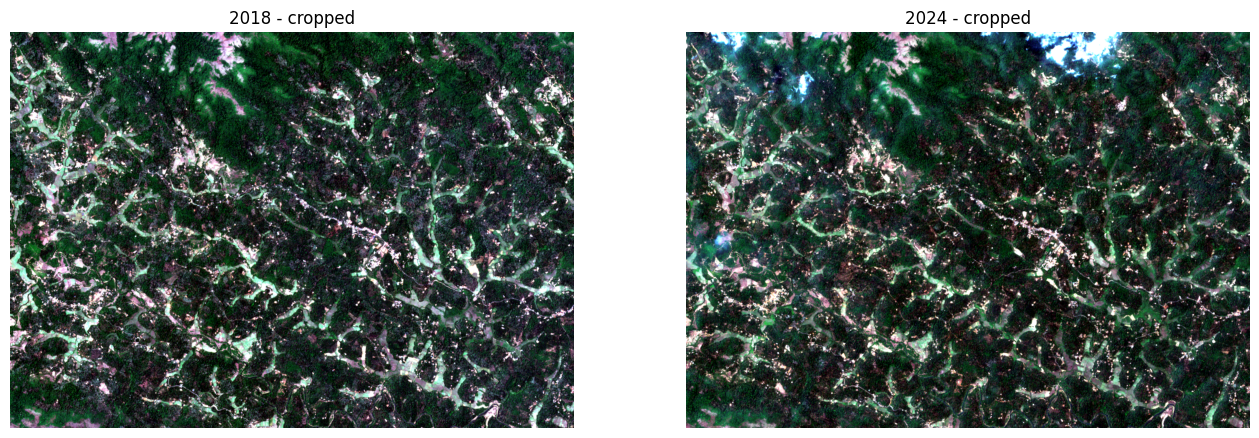

In [36]:
img1 = load_and_combine_rgb_bands(period_1_band_paths, crop_top_frac=0.2)
img2 = load_and_combine_rgb_bands(period_2_band_paths, crop_top_frac=0.2)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(img1); axes[0].set_title("2018 - cropped")
axes[1].imshow(img2); axes[1].set_title("2024 - cropped")
for ax in axes: ax.axis('off')
plt.show()

In [37]:
classified_period_1 = classify_patches(patches_period_1_info, output_patches_period_1_dir, model, test_transform, class_names)
classified_period_2 = classify_patches(patches_period_2_info, output_patches_period_2_dir, model, test_transform, class_names)

print(Counter(p['predicted_class'] for p in classified_period_1))
print(Counter(p['predicted_class'] for p in classified_period_2))

Counter({'HerbVeg': 174, 'SeaLake': 58, 'Forest': 2})
Counter({'HerbVeg': 108, 'SeaLake': 96, 'Forest': 19, 'Highway': 6, 'Industrial': 2, 'Residential': 2, 'PermCrop': 1})


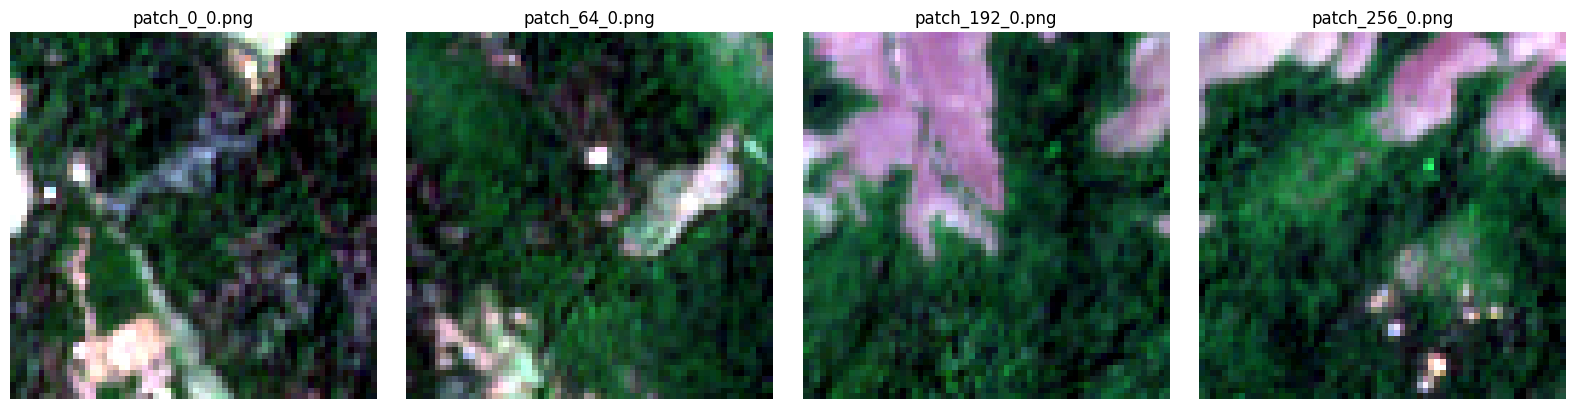

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
herbveg_patches = [p for p in classified_period_1 if p['predicted_class'] == 'HerbVeg']
for ax, patch_info in zip(axes, herbveg_patches[:4]):
    img = Image.open(os.path.join(output_patches_period_1_dir, patch_info['filename']))
    ax.imshow(img)
    ax.set_title(patch_info['filename'])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [39]:
vegetation_classes = {'Forest', 'HerbVeg'}
deforestation_indicator_classes = ['AnnualCrop', 'Pasture', 'Industrial', 'Residential']

deforestation_events = []
for coord, class_p1 in map_period_1.items():
    if coord in map_period_2:
        class_p2 = map_period_2[coord]
        if class_p1 in vegetation_classes and class_p2 in deforestation_indicator_classes:
            deforestation_events.append({'x': coord[0], 'y': coord[1], 'from_class': class_p1, 'to_class': class_p2})

print(f"Vegetation -> non-vegetation events: {len(deforestation_events)}")

Vegetation -> non-vegetation events: 1


{'x': 192, 'y': 64, 'from_class': 'HerbVeg', 'to_class': 'Industrial'}


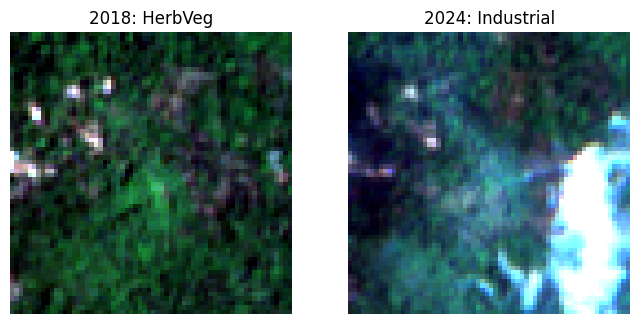

In [40]:
event = deforestation_events[0]
x, y = event['x'], event['y']
print(event)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Image.open(f"{output_patches_period_1_dir}/patch_{x}_{y}.png"))
axes[0].set_title(f"2018: {event['from_class']}")
axes[1].imshow(Image.open(f"{output_patches_period_2_dir}/patch_{x}_{y}.png"))
axes[1].set_title(f"2024: {event['to_class']}")
for ax in axes:
    ax.axis('off')
plt.show()

## 11. Classify each patch

In [ ]:
def classify_patches(patches_info, patch_dir, model, transform, class_names):
    results = []
    model.eval()
    with torch.no_grad():
        for patch in patches_info:
            img_path = os.path.join(patch_dir, patch['filename'])
            img = Image.open(img_path).convert('RGB')
            img_tensor = transform(img).unsqueeze(0).to(device)

            outputs = model(img_tensor)
            _, predicted = torch.max(outputs, 1)
            pred_label = predicted.item()

            results.append({
                'filename': patch['filename'],
                'x_coord': patch['x_coord'],
                'y_coord': patch['y_coord'],
                'predicted_class': class_names[pred_label],
            })
    return results

classified_period_1 = classify_patches(patches_period_1_info, output_patches_period_1_dir,
                                        model, test_transform, class_names)
classified_period_2 = classify_patches(patches_period_2_info, output_patches_period_2_dir,
                                        model, test_transform, class_names)

print("Period 1 class distribution:", Counter(p['predicted_class'] for p in classified_period_1))
print("Period 2 class distribution:", Counter(p['predicted_class'] for p in classified_period_2))

## 12. Compare periods and flag deforestation

A patch is flagged as deforestation if it was classified `Forest` in period 1
and something else (crop, pasture, industrial, or residential) in period 2.

In [ ]:
map_period_1 = {(p['x_coord'], p['y_coord']): p['predicted_class'] for p in classified_period_1}
map_period_2 = {(p['x_coord'], p['y_coord']): p['predicted_class'] for p in classified_period_2}

deforestation_indicator_classes = ['AnnualCrop', 'Pasture', 'Industrial', 'Residential']
deforestation_events = []
all_changes = []

for coord, class_p1 in map_period_1.items():
    if coord in map_period_2:
        class_p2 = map_period_2[coord]
        if class_p1 != class_p2:
            all_changes.append({'x': coord[0], 'y': coord[1], 'from_class': class_p1, 'to_class': class_p2})
        if class_p1 == 'Forest' and class_p2 in deforestation_indicator_classes:
            deforestation_events.append({'x': coord[0], 'y': coord[1], 'from_class': class_p1, 'to_class': class_p2})

print(f"Total matched patches: {len(set(map_period_1) & set(map_period_2))}")
print(f"Total land-cover changes: {len(all_changes)}")
print(f"Deforestation events (Forest -> other): {len(deforestation_events)}")

## 13. Visualize detected deforestation

In [ ]:
if deforestation_events:
    xs = [e['x'] for e in deforestation_events]
    ys = [e['y'] for e in deforestation_events]

    plt.figure(figsize=(10, 8))
    plt.scatter(xs, ys, c='red', s=25, label='Forest -> Other')
    plt.gca().invert_yaxis()
    plt.title('Detected Land Cover Change')
    plt.xlabel('X (pixel)')
    plt.ylabel('Y (pixel)')
    plt.legend()
    plt.savefig('deforestation_map.png', dpi=150)
    plt.show()
else:
    print("No deforestation events detected.")

---
## Notes

- If period 1 or period 2's class distribution is still heavily skewed to one
  class after these fixes, check the patch thumbnails from step 10 first --
  that will tell you whether it's a remaining preprocessing artifact or a
  genuine property of the scene (cloud cover, one dominant land type, strong
  seasonal difference between the two dates).
- For a real deforestation study, download a larger Sentinel-2 bounding box
  (more patches = more reliable statistics) and validate detected events
  against Global Forest Watch data for the same area and dates.
